In [3]:
import sys
from astropy import units as un, constants as cons
from astropy.cosmology import Planck18 as cosmo
import numpy as np
from matplotlib import pyplot as plt
import cmasher as cmr
from astropy.visualization import quantity_support
quantity_support()

sys.path.append('../pysrc/')
from latexify import latexify
import solve_ode as CF
import HaloPotential_new as Halo
import WiersmaCooling as Cool
import ClusterGenerator as CG

import warnings
warnings.simplefilter("ignore", RuntimeWarning)

import importlib # for testing : importlib.reload(module)

In [4]:
# Set Cosmology
rho_crit = cosmo.critical_density0
rho_mean = cosmo.Om0*rho_crit
delta_c =  18 * np.pi**2 + 82 * (cosmo.Om0 - 1) - 39 * (cosmo.Om0 - 1)**2 # Bryan & Norman 98
mu = 0.62 # mean molecular weight

print(cosmo)

FlatLambdaCDM(name="Planck18", H0=67.66 km / (Mpc s), Om0=0.30966, Tcmb0=2.7255 K, Neff=3.046, m_nu=[0.   0.   0.06] eV, Ob0=0.04897)


In [5]:
# Helper function for dervied values
def calc_r_vir(M_vir):
    r_vir = np.power(M_vir / (4/3) / np.pi / delta_c / rho_crit, 1/3)
    return r_vir.to('kpc')

def calc_r_200_c(M_vir):
    r_vir = np.power(M_vir / (4/3) / np.pi / 200 / rho_crit, 1/3)
    return r_vir.to('kpc')
    
def calc_r_200_m(M_vir):
    r_vir = np.power(M_vir / (4/3) / np.pi / 200 / rho_mean, 1/3)
    return r_vir.to('kpc')

def calc_T_vir(M_vir):
    r_vir = calc_r_vir(M_vir)
    vc = np.sqrt(cons.G * M_vir / r_vir)
    temp = mu*cons.m_p*vc**2/cons.k_B/2
    return temp.to('K')

def calc_concentration(M_vir):
    h = cosmo.H0.value/100
    M_ref = 1e12/h * un.Msun
    log_c = 0.905 - 0.101*np.log10(M_vir/M_ref)
    return np.power(10, log_c)

def circular_temp(vc):
    temp = 0.6*mu*cons.m_p*vc**2/cons.k_B
    return temp.to('K')

In [6]:
# Set Halo Parameters
M_vir = 1e11 * un.Msun
r_vir = calc_r_vir(M_vir)
T_vir = calc_T_vir(M_vir)
c_vir = calc_concentration(M_vir) # Concentration parameter
r_200_m = calc_r_200_m(M_vir)
r_200_c = calc_r_200_c(M_vir)
M_gal = 1e10 * un.Msun # Greco et al 2012 for M82
r_gal = 0.015*r_200_c # Kravtsoc 2013 expression for stellar half-mass radius
z_gal = 0.15 * un.kpc # Lim et al 2013 for M82
      
print("Halo Mass: ",M_vir)
print("Virial Radius: ", r_vir)
print("Virial Temperature: ", T_vir)
print("Concentration Parameter: ", c_vir)
print("R200m: ", r_200_m)
print("R200c: ", r_200_c)
print("Disk Mass", M_gal)
print("Disk Scale Radius", r_gal)
print("Disk Scale Height", z_gal)

# Set Halo Potential
nfw = Halo.NFWPotential(M_vir, r_vir, c_vir)
plummer = Halo.PlummerPotential(M_gal, r_gal)
outer = Halo.OuterHaloPotential(rho_mean, r_200_m)
combined = Halo.CombinedPotential(M_vir, r_vir, c_vir, M_gal, r_gal, rho_mean, r_200_m)
miyamoto = Halo.MiyamotoNagaiPotential(M_gal, r_gal, z_gal)

print("NFW Scale Density: ", nfw.rho_s)

Halo Mass:  100000000000.0 solMass
Virial Radius:  122.40315626626357 kpc
Virial Temperature:  131960.7175211719 K
Concentration Parameter:  10.54718269190388
R200m:  144.76736317842207 kpc
R200c:  97.94126310709676 kpc
Disk Mass 10000000000.0 solMass
Disk Scale Radius 1.4691189466064514 kpc
Disk Scale Height 0.15 kpc
NFW Scale Density:  3320989.038326563 solMass / kpc3


In [7]:
# Set Units
cu_length  = 3.0856775809623245e+21 * un.cm # kpc
cu_mass    = 3.036951775493658e+39 * un. g  # number density 0.1 cm^-3 when box size is 1 kpc
cu_time    = 3.15576e+15  * un.s            # 100 Myr

# Derived Units
cu_velocity = cu_length/cu_time # cm/s
cu_density = cu_mass/cu_length**3 # g/cm**3
cu_energy = cu_mass*cu_velocity**2 # erg
cu_pressure = cu_energy/cu_length**3 # erg/cm**3 or dyne/cm^2
cu_temperature = cu_velocity**2*mu*cons.m_p/cons.k_B # K

print(cu_velocity.to('km/s'))
print(cu_temperature.to('K'))

9.777922215131456 km / s
7181.238455976716 K


In [8]:
print("Input Parameters in Code Units")
print(f"r_scale   = {(combined.r_s/cu_length).to('')}")
print(f"rho_scale = {(combined.rho_s/cu_density).to('')}")
print(f"mass_gal  = {(combined.M_gal/cu_mass).to('')}")
print(f"scale_gal = {(combined.a_gal/cu_length).to('')}")
print(f"z_gal     = {(z_gal/cu_length).to('')}")
print(f"r_200     = {(combined.R200/cu_length).to('')}")
print(f"rho_mean  = {(combined.rho_mean/cu_density).to('')}")


Input Parameters in Code Units
r_scale   = 11.605294026167536
rho_scale = 2.1743800590375333
mass_gal  = 6547.387043624801
scale_gal = 1.4691189468583334
z_gal     = 0.15000000002571764
r_200     = 144.7673632032426
rho_mean  = 2.575949929127793e-05


In [9]:
# # Turbulence parameters
# print(15*cu_velocity.to('km/s'))
# urms = ((150 * un.km / un.s)/cu_velocity).to('')
# Lbox = ((500 * un.kpc)/cu_length).to('')
# tcorr = Lbox / (2 * np.pi * urms)
# print(tcorr)
# dedt = urms**3 / (2 *  Lbox)
# print(dedt)

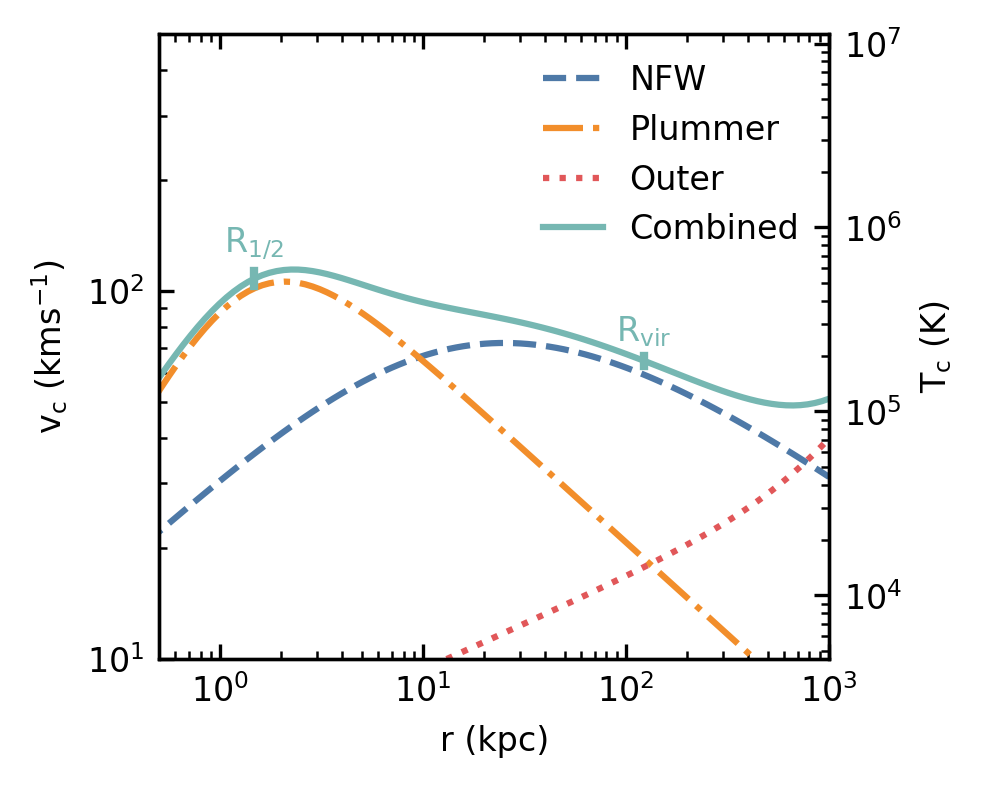

In [30]:
# Plot the circular velocity and its components
rs = np.logspace(-0.5,3,100) * un.kpc

cvs = nfw.vc(rs)
p_cvs = plummer.vc(rs)
o_cvs = outer.vc(rs)
c_cvs = combined.vc(rs)

latexify(columns=1)
plt.figure()
ax=plt.gca()
ax.tick_params(top=True, right=True, which="both", direction='in')
plt.yscale('log')
plt.xscale('log')
plt.xlim(0.5,1000)
plt.ylim(10,500)

plt.plot(rs,cvs,ls='--',label="NFW")
plt.plot(rs,p_cvs,ls='-.',label="Plummer")
plt.plot(rs,o_cvs,ls=':',label="Outer")
plt.plot(rs,c_cvs,ls='-',label="Combined")

tick_length = 2
ticks = [r_vir,r_200_m,r_200_c,r_gal]
tick_labels = [r'R$_{\rm vir}$', r'R$_{\rm 200m}$', r'R$_{\rm 200c}$', r'R$_{\rm 1/2}$']
label_dirs = [-3,1,1,1]

tick_length = 2
plt.plot([r_vir.value,r_vir.value], 
         [combined.vc(r_vir).value - tick_length, combined.vc(r_vir).value + tick_length], 
         color="C3", lw=2)
plt.text(r_vir.value,combined.vc(r_vir).value + tick_length * 2.5, r'R$_{\rm vir}$',
         color="C3", ha='center', va='bottom')

tick_length = 5
plt.plot([r_gal.value,r_gal.value], 
         [combined.vc(r_gal).value - tick_length, combined.vc(r_gal).value + tick_length], 
         color="C3", lw=2)
plt.text(r_gal.value,combined.vc(r_gal).value + tick_length * 2.5, r'R$_{\rm 1/2}$',
         color="C3", ha='center', va='bottom')

plt.xlabel('r (kpc)')
plt.ylabel(r'v$_{\rm c}$ (kms$^{-1}$)')
plt.legend(frameon=False, handlelength=1.8)

ax2 = ax.twinx() 
ax2.tick_params(which="both", direction='in')
ax2.set_yscale('log')
ax2.set_ylabel(r'T$_{\rm c}$ (K)') 
ax2.set_ylim(circular_temp(10*un.km/un.s),circular_temp(500*un.km/un.s))

plt.tight_layout()
# plt.savefig('plots/v_circ.pdf')
plt.show()

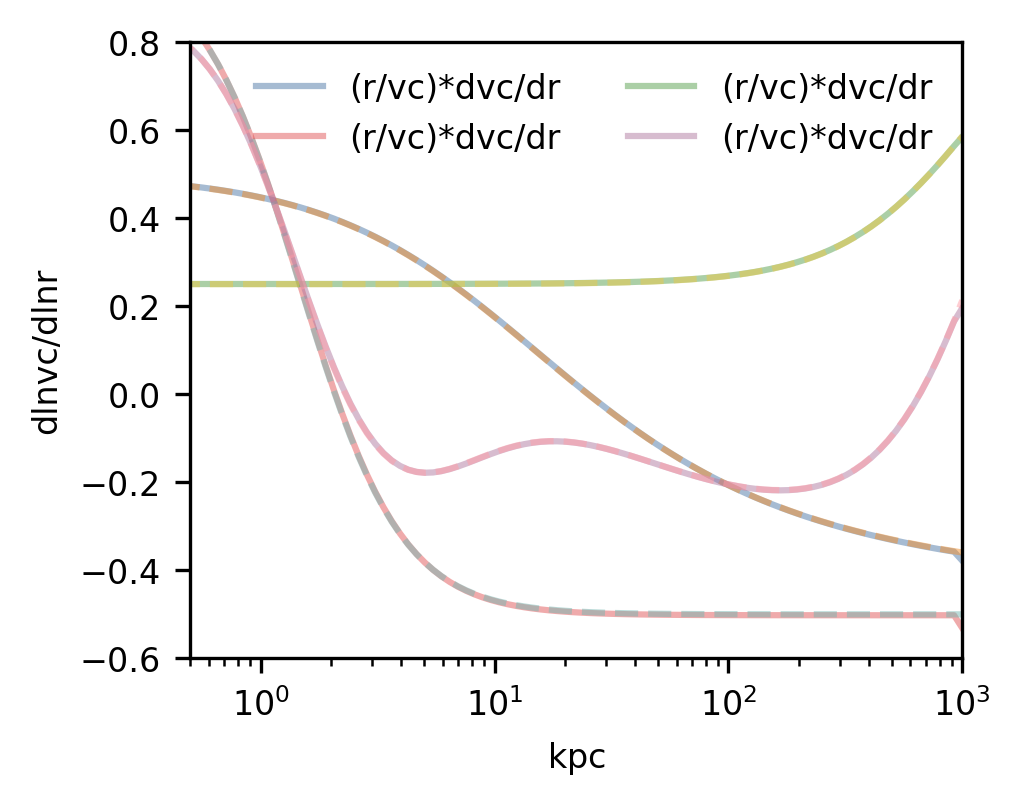

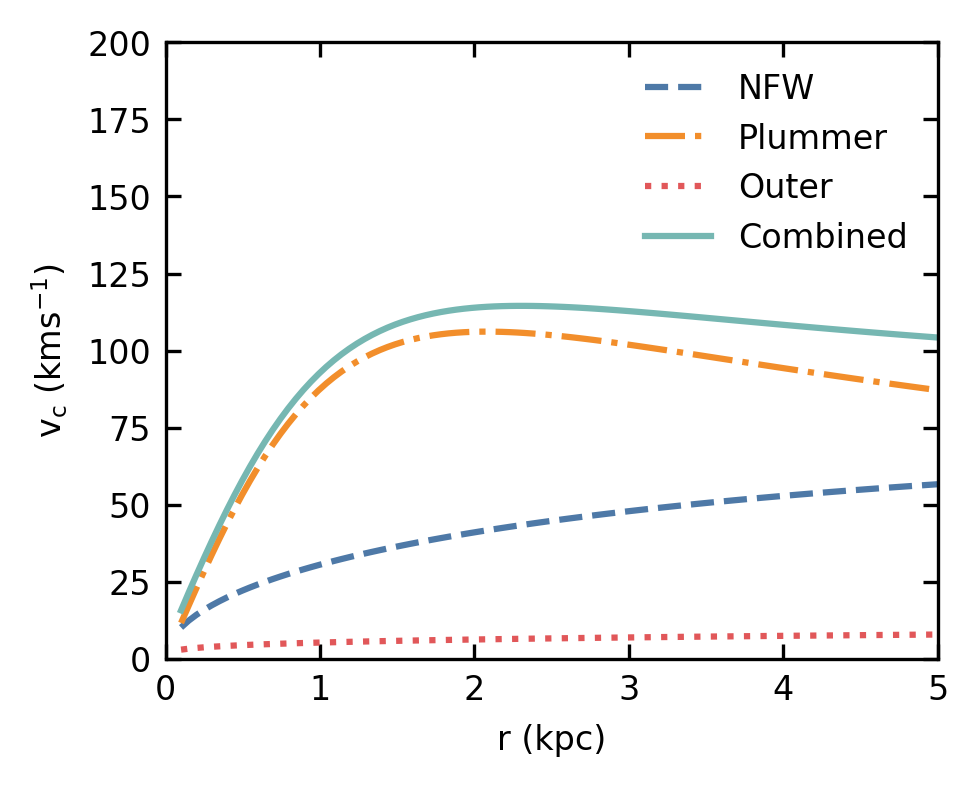

-0.10514452117363872
-0.1051445212235625


In [32]:
# Tests and sanity checks

# Check that dlnvc/dlnr has been implemented correctly 
latexify(columns=1)
plt.figure()

plt.plot(rs,(rs.value/cvs.value)*np.gradient(cvs.value,rs.value),alpha=0.5,label='(r/vc)*dvc/dr')
plt.plot(rs,nfw.dlnvc_dlnR(rs),alpha=0.5,ls='--') #,label='From Class Method')

plt.plot(rs,(rs.value/p_cvs.value)*np.gradient(p_cvs.value,rs.value),alpha=0.5,label='(r/vc)*dvc/dr')
plt.plot(rs,plummer.dlnvc_dlnR(rs),alpha=0.5,ls='--') #,label='From Class Method')

plt.plot(rs,(rs.value/o_cvs.value)*np.gradient(o_cvs.value,rs.value),alpha=0.5,label='(r/vc)*dvc/dr')
plt.plot(rs,outer.dlnvc_dlnR(rs),alpha=0.5,ls='--') #,label='From Class Method')

plt.plot(rs,(rs.value/c_cvs.value)*np.gradient(c_cvs.value,rs.value),alpha=0.5,label='(r/vc)*dvc/dr')
plt.plot(rs,combined.dlnvc_dlnR(rs),alpha=0.5,ls='--') #,label='From Class Method')

plt.ylabel('dlnvc/dlnr')
plt.legend(frameon=False, ncols=2)
plt.xscale('log')
plt.xlim(0.5,1000)
plt.ylim(-0.6,0.8)
plt.show()

# Plot the circular velocity and its components
# This is in the inner region to compare with observed rotation curves in Greco et al 2012 for M82
# The main difference is we are using a R1/2 that is larger by about a factor of 2
rs = np.linspace(0.1,5,100) * un.kpc

cvs = nfw.vc(rs)
p_cvs = plummer.vc(rs)
o_cvs = outer.vc(rs)
c_cvs = combined.vc(rs)

latexify(columns=1)
plt.figure()
ax=plt.gca()
ax.tick_params(top=True, right=True, which="both", direction='in')
plt.xlim(0,5)
plt.ylim(0,200)

plt.plot(rs,cvs,ls='--',label="NFW")
plt.plot(rs,p_cvs,ls='-.',label="Plummer")
plt.plot(rs,o_cvs,ls=':',label="Outer")
plt.plot(rs,c_cvs,ls='-',label="Combined")

plt.xlabel('r (kpc)')
plt.ylabel(r'v$_{\rm c}$ (kms$^{-1}$)')
plt.legend(frameon = False)

plt.show()

# Checking that dphidr calculated two different ways are the same for the combined potential
un_phi = cu_velocity**2

x1l = 125.976562*un.kpc
x2v = 110.351562*un.kpc
x3v = -235.351562*un.kpc

r_ = np.sqrt(x1l**2 + x2v**2 + x3v**2)

vc = combined.vc(r_)
vc_ = (vc/cu_velocity).to('')
dphi_dr = vc_**2/(r_/cu_length).to('')
print(-dphi_dr)

delta_r = 0.00005*un.kpc
phil = combined.Phi(r_ - delta_r)
phir = combined.Phi(r_ + delta_r)
dphi_dr_= (phil-phir)/(2*delta_r)
print((dphi_dr_*cu_length/cu_velocity**2).to(''))

Velocities updated with new profile
Mean velocity magnitude: 7.167
Velocity range: [1.067, 9.495]

Cluster Statistics:
----------------------------------------
n_clusters: 1000.00
total_mass_msun: 4.41e+07
mean_mass_msun: 4.41e+04
median_mass_msun: 1.97e+04
std_mass_msun: 7.87e+04
min_mass_msun: 1.00e+04
max_mass_msun: 9.73e+05
mean_radius_pc: 670.96
max_radius_pc: 999.71
mass_range_decades: 1.99e+00
mean_v_mag: 7.17
std_v_mag: 2.01
min_z_pc: -9.99
max_z_pc: 9.99
mean_z_pc: -0.19
mean_vz: -0.05
std_vz: 1.00


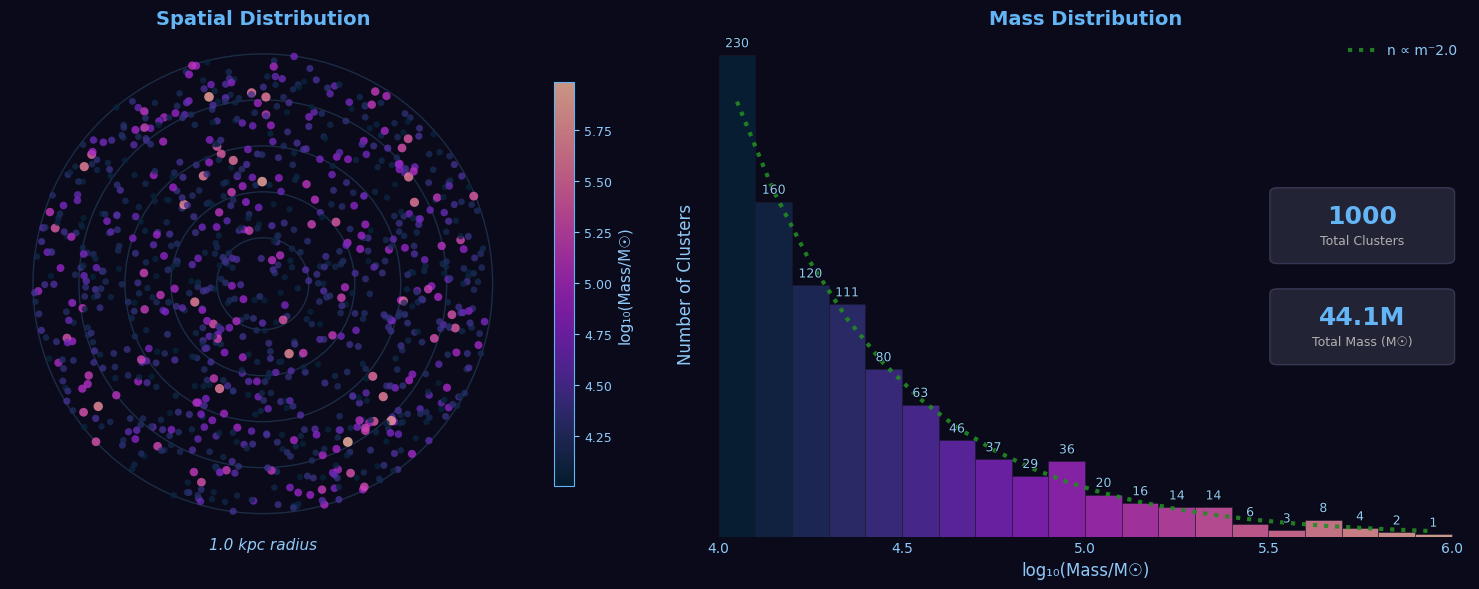

In [ ]:
# Generate Star Clusters

# Create generator with custom parameters
params = CG.ClusterParameters(
    n_clusters=1000,
    mass_range=(1e4, 1e6),
    alpha=2.0,
    radius_kpc=1.0
)

generator = CG.StarClusterGenerator(params)

# Generate clusters
clusters = generator.generate_clusters(seed=42)

# Set circular velocities
def get_vcirc(r):
    return (combined.vc(r*un.pc)/cu_velocity).to('')
generator.set_velocity_profile(get_vcirc)

# Display statistics
stats = generator.get_statistics()
print("\nCluster Statistics:")
print("-" * 40)
for key, value in stats.items():
    if 'mass' in key:
        print(f"{key}: {value:.2e}")
    else:
        print(f"{key}: {value:.2f}")

# Create visualization
generator.plot_distributions(save_fig=False, filename='plots/clusters.png')

# Save data to table
# generator.save_to_txt("tables/clusters.txt")

In [11]:
# Set Cooling
cooling = Cool.Wiersma_Cooling(Z2Zsun=1/3,z=0)

In [36]:
# Generate CGM steady-state cooling flow solution

max_step = 0.01                          # lowest resolution of solution in ln(r)
R_min    = 1*un.kpc                      # inner radius of supersonic part of solution
R_max    = 230*un.kpc                    # outer radius of integration
R_sonic  = 100*un.kpc                    # sonic radii

print('R_sonic = %s'%R_sonic)
sol = CF.shoot_from_R_sonic(combined,cooling,R_sonic,R_max,R_min,max_step=max_step,verbose=True)

R_sonic = 100.0 kpc
Integrating with v_c^2/c_s^2 (R_sonic) = 1.000010 ... Stop reason: Starts unbound
Integrating with v_c^2/c_s^2 (R_sonic) = 1.500005 ... Stop reason: Unbound (Maximum r = 107 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.750002 ... Stop reason: No transsonic solutions
Integrating with v_c^2/c_s^2 (R_sonic) = 1.625004 ... Stop reason: Unbound (Maximum r = 190 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.687503 ... Stop reason: Sonic point (Maximum r = 143 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.656253 ... Stop reason: Sonic point (Maximum r = 185 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.640629 ... Stop reason: Sonic point (Maximum r = 211 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.632816 ... Stop reason: Sonic point (Maximum r = 226 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.628910 ... Stop reason: Unbound (Maximum r = 208 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.630863 ... Stop reason: Unbound (Maximum r = 228 kpc)
Integrating wit

In [38]:
# Save file

"""
The file format is a header line followed by data columns:
# r T rho v
r_1 T_1 rho_1 v_1
r_2 T_2 rho_2 v_2
"""

Rs = (sol.Rs/cu_length).to('').value
Ts = (sol.Ts/cu_temperature).to('').value
rhos = (sol.rhos/cu_density).to('').value
vs = (sol.vs/cu_velocity).to('').value

# Combine arrays into a single array for saving
data = np.column_stack((Rs, Ts, rhos, vs))

# Save to file with header
header = "# r T rho v"
filename = "tables/cgm_profiles.txt"
# np.savetxt(filename, data, header=header)

print(f"Profiles saved to {filename}")

Profiles saved to tables/cgm_profiles.txt


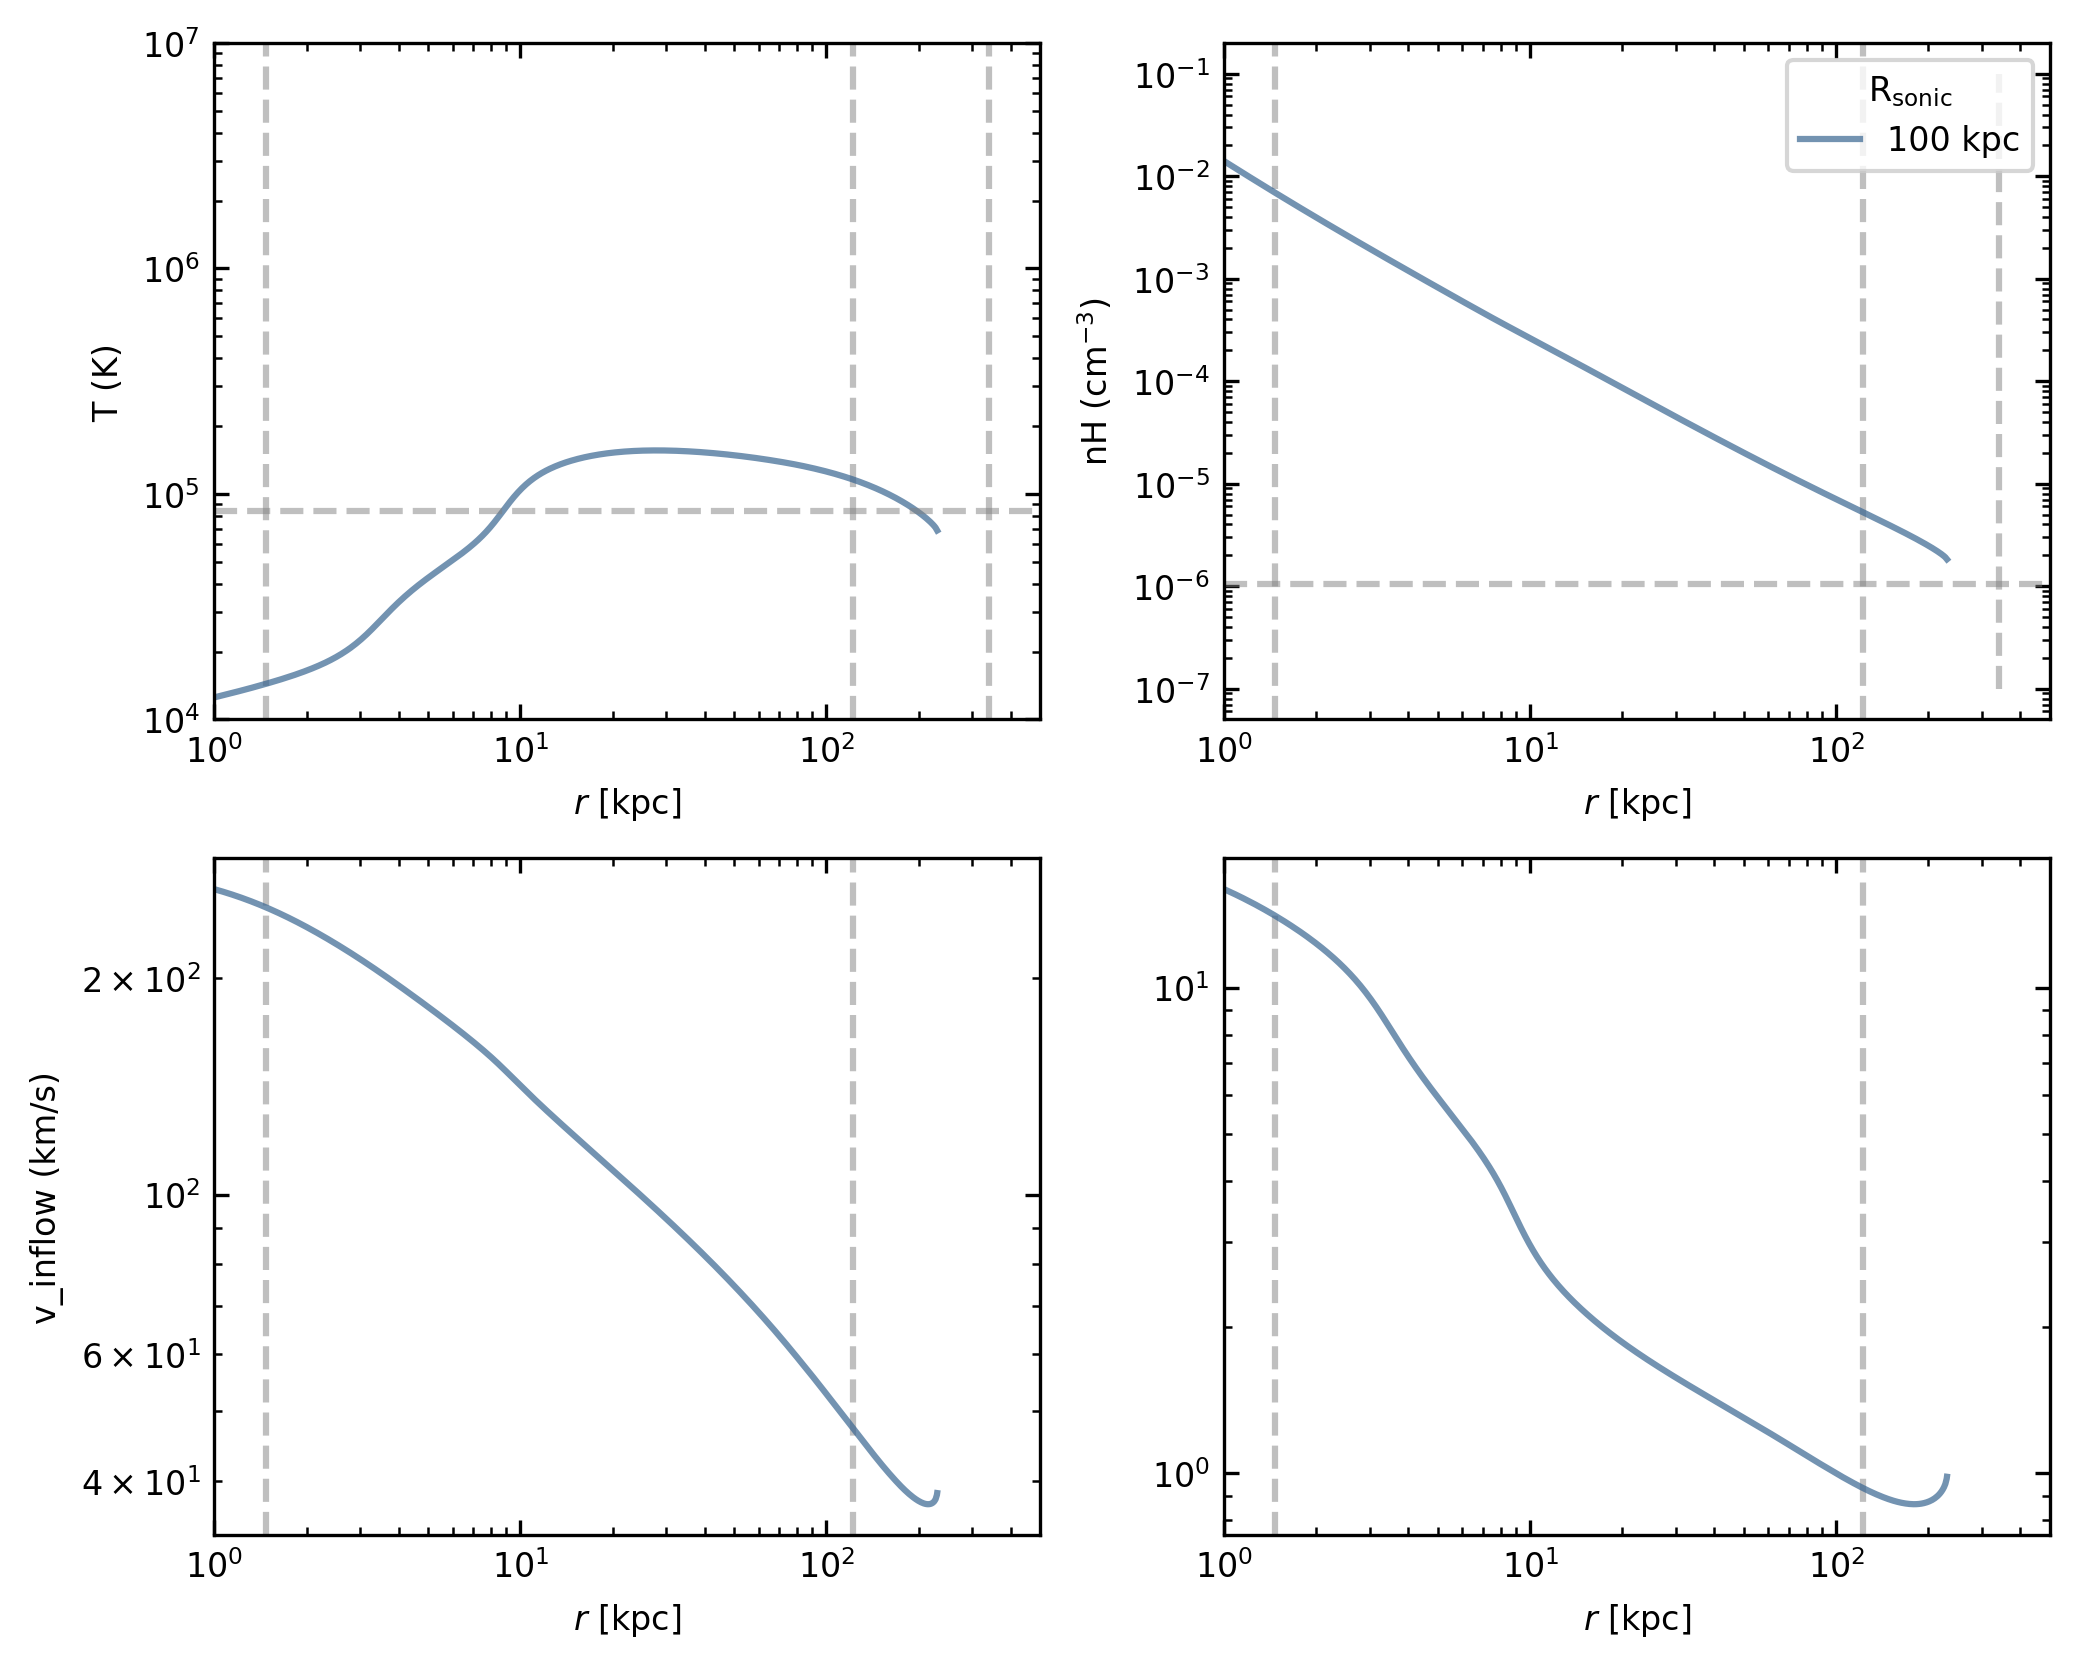

In [39]:
latexify(columns=2)
fig, axs = plt.subplots(2, 2)

for ax in axs.flatten():
    ax.set_xlabel(r'$r$ [kpc]')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.tick_params(top=True, right=True, which="both", direction='in')
    ax.set_xlim(1,500)

    ax.axvline(r_gal,c='.5',ls='--',alpha=0.5)
    ax.axvline(r_vir,c='.5',ls='--',alpha=0.5)

colors = cmr.lavender(np.linspace(0.2,0.8,10))

res = sol
i=5

axs[0, 0].plot(res.Rs, res.Ts, alpha=0.7, color=colors[i])
axs[0, 0].hlines(83716.961983,1,500,ls='--',color='.5',alpha=0.5)
axs[0, 0].vlines(340,1e4,1e7,ls='--',color='.5',alpha=0.5)
axs[0, 0].set_ylabel(r'T (K)')
axs[0, 0].set_ylim(1e4,1e7)

axs[0, 1].plot(res.Rs, res.nHs, alpha=0.7, color=colors[i], label=f'100 kpc')
axs[0, 1].hlines(0.104269/1e5,1,500,ls='--',color='.5',alpha=0.5)
axs[0, 1].vlines(340, 1e-7, 1e-1, ls='--', color='.5', alpha=0.5)
axs[0, 1].set_ylabel(r'nH (cm$^{-3}$)')
# axs[0, 1].set_ylim(1e-5,1)

axs[1, 0].plot(res.Rs, res.vs, alpha=0.7, color=colors[i])
axs[1, 0].set_ylabel(r'v_inflow (km/s)')
# axs[1, 0].set_ylim(0.03,30)

axs[1, 1].plot(res.Rs, res.Ms, alpha=0.7, color=colors[i])
# axs[1, 1].set_ylabel(r'$t_{\rm cool}/t_{\rm flow}$')
# axs[1, 1].set_ylim(0.03,30)
# axs[1, 1].axhline(1.,c='.5',ls='--',alpha=0.5)

axs[0, 1].legend(frameon=True, loc='upper right', title=r'R$_{\rm sonic}$', handlelength=1.8)
plt.tight_layout()
# plt.savefig('./plots/cf_sols.pdf',dpi=150)
plt.show()

In [1]:
## Compute rho(r) for the galactic disk

# Compute surface density profile
M_gas = 2.5e9 * un.Msun # Greco et al 2012 for M82
Sigma_0 = M_gas/(2*np.pi*r_gal**2)
T_disk = 1e4 * un.K # Temperature of isothermal disk

def phi_total(R,z):
    return miyamoto.Phi(R,z).to('km^2/s^2')

def midplane_density(R):
    sigma = Sigma_0*np.exp(-R/r_gal)
    phi0 = phi_total(R, 0*un.kpc)
    # Numerically integrate the density at R over all z
    def f(z):
        z = z*un.kpc
        phi = phi_total(R,z)
        cs2 = (cons.k_B*T_disk/mu/cons.m_p).to('km^2/s^2') # use the isothermal and not adiabatic sound speed
        return np.exp((-(phi-phi0)/cs2).to('').value)
    zlim = 10*(z_gal/un.kpc).to('')
    integral = scipy.integrate.quad(f,-zlim,zlim) # integrate vertically over 10 scale heights
    return sigma/integral[0]/(1.0 * un.kpc)

disk_Rs = np.logspace(-3,np.log10(20),100) * un.kpc
midplane_rhos = [midplane_density(r) for r in disk_Rs]

rho0 = midplane_rhos[0]
def f(z):
    phi0 = phi_total(0*un.kpc,0*un.kpc)
    phi = phi_total(0*un.kpc,z)
    cs2 = (cons.k_B*T_disk/mu/cons.m_p).to('km^2/s^2')
    return np.exp((-(phi-phi0)/cs2).to(''))
center_rhos = rho0*f(disk_Rs)

def rho_to_n(rhos):
    return np.array([(rho/mu/cons.m_p).to('cm**-3').value for rho in rhos])*un.cm**-3

midplane_ns = rho_to_n(midplane_rhos)
center_ns = rho_to_n(center_rhos)

NameError: name 'un' is not defined

In [9]:
rho1 = midplane_rhos[80]
def f1(z):
    phi0 = phi_total(disk_Rs[80],0*un.kpc)
    phi = phi_total(disk_Rs[80],z)
    cs2 = (cons.k_B*T_disk/mu/cons.m_p).to('km^2/s^2')
    return np.exp((-(phi-phi0)/cs2).to(''))
center_rhos_1 = rho1*f1(disk_Rs)
center_ns_1 = rho_to_n(center_rhos_1)

In [141]:
rho2 = midplane_rhos[73]
def f2(z):
    phi0 = phi_total(disk_Rs[73],0*un.kpc)
    phi = phi_total(disk_Rs[73],z)
    cs2 = (cons.k_B*T_disk/mu/cons.m_p).to('km^2/s^2')
    return np.exp((-(phi-phi0)/cs2).to(''))
center_rhos_2 = rho2*f2(disk_Rs)
center_ns_2 = rho_to_n(center_rhos_2)

In [152]:
h_scale_radius = 0.64 * r_gal
h_scale_height = 0.33 * z_gal
h_scale_alpha = 0.002

fit_norm_rho = midplane_density(0*un.kpc)
fit_norm = rho_to_n([fit_norm_rho])[0]
fit_ns_1 = np.array([fit_norm.value*np.exp(-r/h_scale_radius) for r in disk_Rs])
fit_ns_2 = np.array([fit_ns_1[0]*np.exp(-(r/(h_scale_height))**2) for r in disk_Rs])
fit_ns_3 = np.array([fit_ns_1[80]*np.exp(-(r/np.sqrt(h_scale_height**2+h_scale_alpha*disk_Rs[80]**2))**2) for r in disk_Rs])
fit_ns_4 = np.array([fit_ns_1[73]*np.exp(-(r/np.sqrt(h_scale_height**2+h_scale_alpha*disk_Rs[73]**2))**2) for r in disk_Rs])

# Print in Physical Units
print("Physical Units:")
print("Normalization: ", fit_norm_rho)
print("Heating Scale Radius: ", h_scale_radius)
print("Heating Scale Height: ", h_scale_height)
print(" ")

# Print in Code Units
print("Code Units:")
print("hscale_norm   =", (fit_norm_rho/cu_density).to(''))
print("hscale_radius =", (h_scale_radius/cu_length).to(''))
print("hscale_height =", (h_scale_height/cu_length).to(''))
print("hscale_alpha  =", h_scale_alpha)

Physical Units:
Normalization:  2058308408.6806467 solMass / kpc3
Heating Scale Radius:  0.9402361258281289 kpc
Heating Scale Height:  0.0495 kpc
 
Code Units:
hscale_norm   = 1347.6541799847946
hscale_radius = 0.9402361259893334
hscale_height = 0.04950000000848683
hscale_alpha  = 0.002


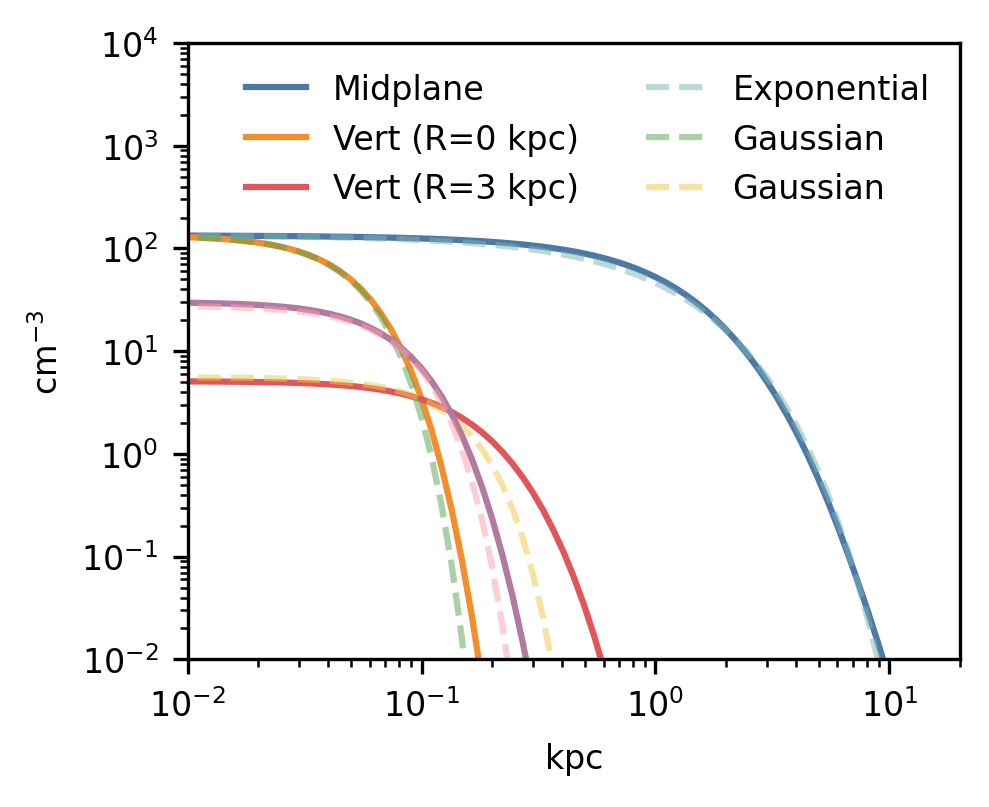

In [150]:
latexify(columns=1)
plt.figure()
plt.plot(disk_Rs, midplane_ns, label='Midplane')
plt.plot(disk_Rs, center_ns, label='Vert (R=0 kpc)')
plt.plot(disk_Rs, center_ns_1, label=f'Vert (R={disk_Rs[80]:.0f})')
plt.plot(disk_Rs, fit_ns_1, ls='--',alpha=0.5,label='Exponential')
plt.plot(disk_Rs, fit_ns_2, ls='--',alpha=0.5,label='Gaussian')
plt.plot(disk_Rs, fit_ns_3, ls='--',alpha=0.5,label='Gaussian')

plt.plot(disk_Rs, center_ns_2)
plt.plot(disk_Rs, fit_ns_4, ls='--',alpha=0.5)

plt.loglog()
# plt.xscale('log')
plt.ylim(1e-2,1e4)
plt.xlim(1e-2,20)
plt.legend(loc = 'upper right', ncols=2, frameon=False, handlelength=1.8)
plt.show()

In [74]:
# Save file
Rs = (disk_Rs/cu_length).to('').value
Ts = np.array([(T_disk/cu_temperature).to('').value for _ in disk_Rs])
rhos = np.array([(m/cu_density).to('').value for m in midplane_rhos])
vs = np.array([0. for _ in disk_Rs])

"""
The file format is a header line followed by data columns:
# r T rho v
r_1 T_1 rho_1 v_1
r_2 T_2 rho_2 v_2
"""

# Combine arrays into a single array for saving
data = np.column_stack((Rs, Ts, rhos, vs))

# Save to file with header
header = "# r T rho v"
filename = "disk_profiles.txt"
np.savetxt(filename, data, header=header)

print(f"Profiles saved to {filename}")

Profiles saved to disk_profiles.txt
